In [4]:
#Dataset Exploration

import pandas as pd

# 1. Load Dataset
file_path = r"E:\valorant-stats.csv"
df = pd.read_csv(file_path)

# 2. Display Shape
print("=== 1. Dataset Shape ===")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print("-" * 40)

# 3. Display Data Types
print("=== 2. Data Types ===")
print(df.dtypes)
print("-" * 40)

# 4. Display Summary Statistics
print("=== 3. Summary Statistics (Numerical) ===")
print(df.describe())
print("\n=== Summary Statistics (Categorical) ===")
print(df.describe(include=["object"]))
print("-" * 40)

# 5. Display Missing Values
print("=== 4. Missing Values ===")
print(df.isnull().sum())
print("-" * 40)

# 6. Display Duplicate Records
print("=== 5. Duplicate Records ===")
print(f"Total Duplicates: {df.duplicated().sum()}")
print("-" * 40)

# 7. Display Class Distribution (Categorical Columns)
print("=== 6. Class Distribution ===")
print("\n-- Weapon Type Distribution --")
print(df["Weapon Type"].value_counts())

print("\n-- Wall Penetration Distribution --")
print(df["Wall Penetration"].value_counts())

=== 1. Dataset Shape ===
Rows: 17, Columns: 15
----------------------------------------
=== 2. Data Types ===
Name                     str
Weapon Type              str
Price                  int64
Fire Rate            float64
Wall Penetration         str
Magazine Capacity      int64
HDMG_0                 int64
BDMG_0                 int64
LDMG_0                 int64
HDMG_1                 int64
BDMG_1                 int64
LDMG_1                 int64
HDMG_2                 int64
BDMG_2                 int64
LDMG_2                 int64
dtype: object
----------------------------------------
=== 3. Summary Statistics (Numerical) ===
             Price  Fire Rate  Magazine Capacity      HDMG_0      BDMG_0  \
count    17.000000  17.000000          17.000000   17.000000   17.000000   
mean   1629.411765   7.463529          21.235294  114.000000   43.588235   
std    1232.763514   4.779767          23.823647   63.295932   34.483798   
min       0.000000   0.750000           2.000000   34.

C:\Users\USER01\AppData\Local\Temp\ipykernel_864\1323596861.py:23: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df.describe(include=["object"]))


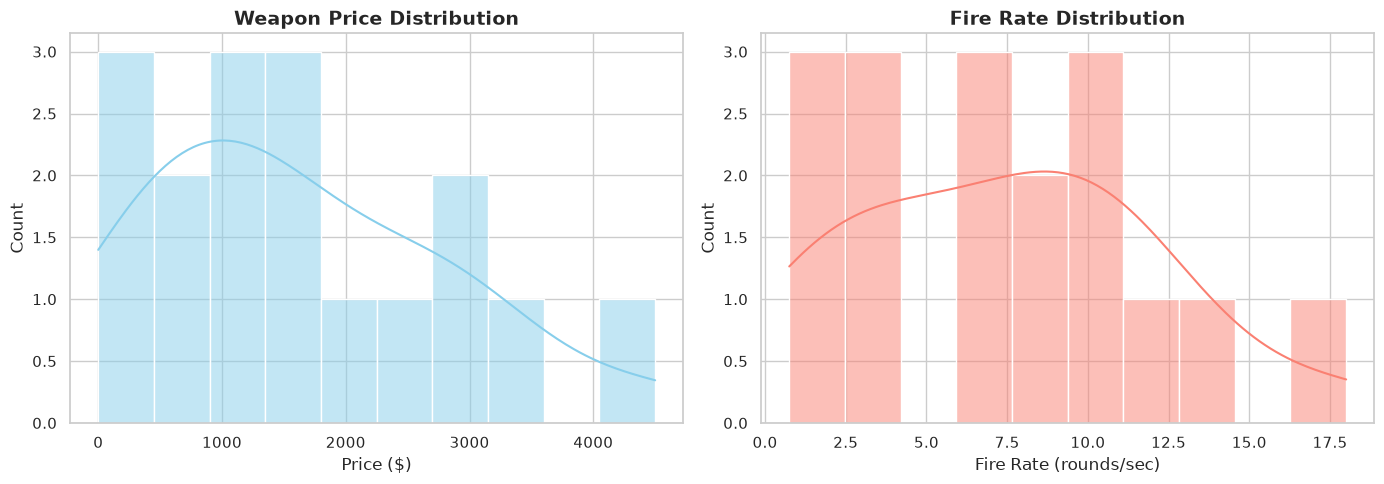

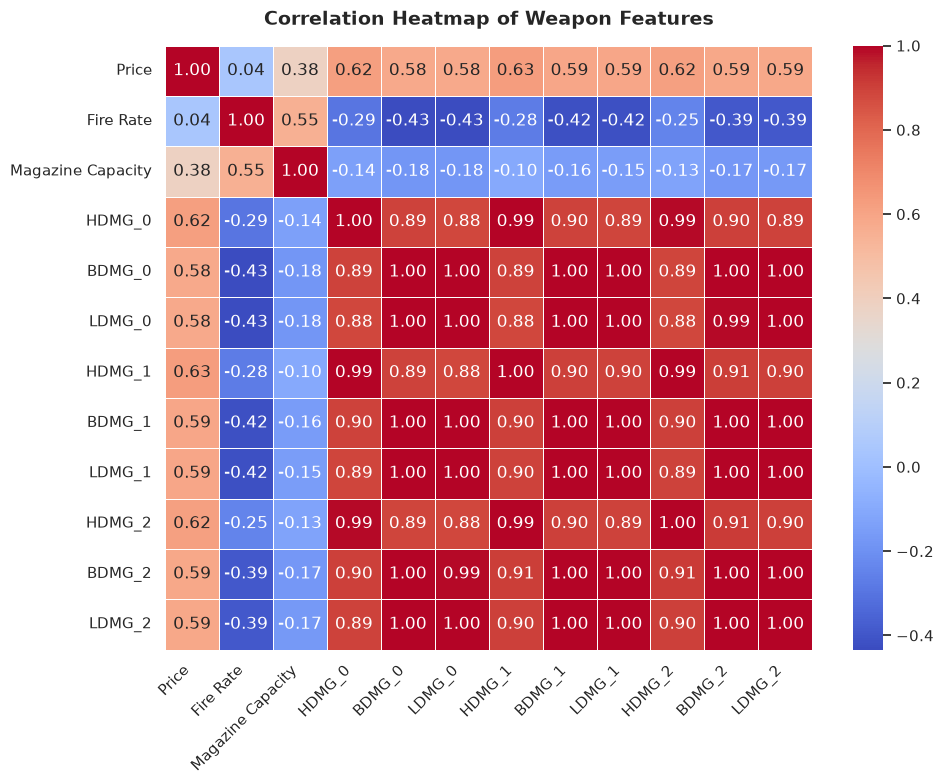

In [6]:
#Data Visualization 

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. โหลดข้อมูล (ใช้ path ตามไดรฟ์ของคุณ เช่น r"E:\valorant-stats.csv")
file_path = r"E:\valorant-stats.csv"
df = pd.read_csv(file_path)

# ตั้งค่าสไตล์การวาดกราฟ
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'

# ==========================================
# 1. Histogram (การกระจายตัวของราคาและอัตราการยิง)
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1.1 Histogram: Price Distribution
sns.histplot(data=df, x="Price", bins=10, kde=True, color="skyblue", ax=axes[0])
axes[0].set_title("Weapon Price Distribution", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Price ($)", fontsize=12)
axes[0].set_ylabel("Count", fontsize=12)

# 1.2 Histogram: Fire Rate Distribution
sns.histplot(data=df, x="Fire Rate", bins=10, kde=True, color="salmon", ax=axes[1])
axes[1].set_title("Fire Rate Distribution", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Fire Rate (rounds/sec)", fontsize=12)
axes[1].set_ylabel("Count", fontsize=12)

plt.tight_layout()
plt.show()

# ==========================================
# 2. Correlation Heatmap (ความสัมพันธ์ของตัวเลข)
# ==========================================
plt.figure(figsize=(10, 8))

# เลือกเฉพาะคอลัมน์ที่เป็นตัวเลขเพื่อนำมาหา Correlation
numeric_cols = df.select_dtypes(include=['float64', 'int64'])
corr = numeric_cols.corr()

# วาด Heatmap
sns.heatmap(
    corr, 
    annot=True,          # แสดงตัวเลขสหสัมพันธ์บนช่อง
    fmt=".2f",           # ทศนิยม 2 ตำแหน่ง
    cmap="coolwarm",     # โทนสี (น้ำเงิน=ลบ, แดง=บวก)
    linewidths=0.5,      # เส้นแบ่งช่อง
    cbar=True
)

plt.title("Correlation Heatmap of Weapon Features", fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [7]:
import pandas as pd
import numpy as np

# 1. Load Dataset
file_path = r"E:\valorant-stats.csv"  # เปลี่ยนเป็น Path ไฟล์ของคุณ
df = pd.read_csv(file_path)

print("=== 📌 1. ข้อมูลเดิมก่อน Cleaning ===")
print(f"จำนวนแถวและคอลัมน์เดิม: {df.shape}")

# เก็บค่า Mean และ Median ก่อนทำความสะอาดข้อมูล
mean_before = df.mean(numeric_only=True)
median_before = df.median(numeric_only=True)

# สร้าง Copy สำหรับทำ Cleaning
df_clean = df.copy()

# ==========================================
# 2. PERFORM DATA CLEANING
# ==========================================

# 2.1 Missing Value Handling (การจัดการค่าสูญหาย)
# หากมีค่า NaN ให้แทนที่ตัวเลขด้วย Median และข้อความด้วย Mode (หรือใช้ dropna)
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
df_clean[numeric_cols] = df_clean[numeric_cols].fillna(df_clean[numeric_cols].median())

object_cols = df_clean.select_dtypes(include=['object']).columns
for col in object_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

# 2.2 Duplicate Removal (การลบข้อมูลที่ซ้ำกัน)
df_clean = df_clean.drop_duplicates()

# 2.3 Incorrect Data Correction (การแก้ไขข้อมูลที่ไม่ถูกต้อง/ช่องว่างเกิน)
for col in object_cols:
    df_clean[col] = df_clean[col].astype(str).str.strip()  # ตัดช่องว่างหน้า-หลังข้อความ

# 2.4 Data Type Conversion (การแปลงประเภทข้อมูล)
df_clean['Weapon Type'] = df_clean['Weapon Type'].astype('category')
df_clean['Wall Penetration'] = df_clean['Wall Penetration'].astype('category')
df_clean['Price'] = df_clean['Price'].astype('float64')

print("\n=== ✅ 2. ข้อมูลหลัง Cleaning ===")
print(f"จำนวนแถวและคอลัมน์หลัง Clean: {df_clean.shape}")
print("\nData Types หลังแปลงค่า:")
print(df_clean.dtypes)

# ==========================================
# 3. COMPARE MEAN & MEDIAN
# ==========================================
mean_after = df_clean.mean(numeric_only=True)
median_after = df_clean.median(numeric_only=True)

# สรุปตารางเปรียบเทียบ
comparison_df = pd.DataFrame({
    'Mean (Before)': mean_before,
    'Mean (After)': mean_after,
    'Median (Before)': median_before,
    'Median (After)': median_after
})

print("\n=== 📊 3. ตารางเปรียบเทียบ Mean & Median (Before vs After) ===")
print(comparison_df.round(2))

=== 📌 1. ข้อมูลเดิมก่อน Cleaning ===
จำนวนแถวและคอลัมน์เดิม: (17, 15)

=== ✅ 2. ข้อมูลหลัง Cleaning ===
จำนวนแถวและคอลัมน์หลัง Clean: (17, 15)

Data Types หลังแปลงค่า:
Name                      str
Weapon Type          category
Price                 float64
Fire Rate             float64
Wall Penetration     category
Magazine Capacity       int64
HDMG_0                  int64
BDMG_0                  int64
LDMG_0                  int64
HDMG_1                  int64
BDMG_1                  int64
LDMG_1                  int64
HDMG_2                  int64
BDMG_2                  int64
LDMG_2                  int64
dtype: object

=== 📊 3. ตารางเปรียบเทียบ Mean & Median (Before vs After) ===
                   Mean (Before)  Mean (After)  Median (Before)  \
Price                    1629.41       1629.41          1500.00   
Fire Rate                   7.46          7.46             6.75   
Magazine Capacity          21.24         21.24            13.00   
HDMG_0                    114.00     

C:\Users\USER01\AppData\Local\Temp\ipykernel_864\1369530348.py:27: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_cols = df_clean.select_dtypes(include=['object']).columns


In [10]:
#Feature Engineering

import pandas as pd
from sklearn.preprocessing import LabelEncoder

# 1. โหลดข้อมูล
file_path = r"E:\valorant-stats.csv"  
df = pd.read_csv(file_path)

# ==========================================
# 1. Label Encoding
# (เหมาะสำหรับข้อมูลที่มีลำดับ หรือต้องการแปลงเป็นตัวเลข 0, 1, 2, ...)
# ==========================================
df_label = df.copy()

# สร้าง LabelEncoder object
le_weapon = LabelEncoder()
le_wall = LabelEncoder()

# แปลงคอลัมน์ตัวอักษรเป็นตัวเลข
df_label['Weapon Type_Encoded'] = le_weapon.fit_transform(df_label['Weapon Type'])
df_label['Wall Penetration_Encoded'] = le_wall.fit_transform(df_label['Wall Penetration'])

print("=== 1. ผลลัพธ์ Label Encoding (ตัวอย่าง 5 แถวแรก) ===")
print(df_label[['Name', 'Weapon Type', 'Weapon Type_Encoded', 'Wall Penetration', 'Wall Penetration_Encoded']].head())
print("-" * 60)

# ==========================================
# 2. One-Hot Encoding
# (เหมาะสำหรับข้อมูลไม่มีลำดับ โดยแยกคอลัมน์เป็น 0 และ 1)
# ==========================================
# ใช้ pd.get_dummies เพื่อแปลงคอลัมน์ Categorical
df_onehot = pd.get_dummies(df, columns=['Weapon Type', 'Wall Penetration'], dtype=int)

print("=== 2. ผลลัพธ์ One-Hot Encoding (คอลัมน์ที่ถูกสร้างขึ้นใหม่) ===")
encoded_cols = [col for col in df_onehot.columns if 'Weapon Type_' in col or 'Wall Penetration_' in col]
print(df_onehot[['Name'] + encoded_cols].head())

=== 1. ผลลัพธ์ Label Encoding (ตัวอย่าง 5 แถวแรก) ===
      Name Weapon Type  Weapon Type_Encoded Wall Penetration  \
0  Classic     Sidearm                    4              Low   
1   Shorty     Sidearm                    4              Low   
2   Frenzy     Sidearm                    4              Low   
3    Ghost     Sidearm                    4           Medium   
4  Sheriff     Sidearm                    4             High   

   Wall Penetration_Encoded  
0                         1  
1                         1  
2                         1  
3                         2  
4                         0  
------------------------------------------------------------
=== 2. ผลลัพธ์ One-Hot Encoding (คอลัมน์ที่ถูกสร้างขึ้นใหม่) ===
      Name  Weapon Type_Heavy  Weapon Type_Rifle  Weapon Type_SMG  \
0  Classic                  0                  0                0   
1   Shorty                  0                  0                0   
2   Frenzy                  0                  0